In [1]:
import cv2
from scipy.ndimage import zoom
import glob
import numpy as np
from scipy.ndimage import center_of_mass
from os.path import sep
import umap
import matplotlib.pyplot as plt
import scienceplots

def bec_crop_centre(bec_file: str, files: list[str], size: int, root: str):
    """
    New image cropping fn, parse in file of bec image and will take as center for all other images.
    V simple don't know why I didn't think of this before
    """
    bec_im = cv2.imread(bec_file, 0)
    cx, cy = center_of_mass(bec_im ** 3)

    for f in files:
        image = cv2.imread(f, 0)
        name = f.split(sep)[-1][:-4]

        image_crop = image[int(int(cx) - size[0] / 2):int(int(cx) + size[0] / 2),
                     int(int(cy) - size[1] / 2):int(int(cy) + size[1] / 2)]


def read(bec_file: str, files: list[str]):
    img_features = []

    all_info = [file.split('_') for file in files]
    int_times = [float(file[4]) for file in all_info]
    bec_im = cv2.imread(bec_file, 0)
    cx, cy = center_of_mass(bec_im ** 3)

    for i, f in enumerate(files):
        image = cv2.imread(f, 0)


        image = zoom(image, (224 / image.shape[0], 244 / image.shape[1]))

        size = (224, 224)
        image_crop = image[int(int(cx) - size[0] / 2):int(int(cx) + size[0] / 2),
                     int(int(cy) - size[1] / 2):int(int(cy) + size[1] / 2)]

        image = image.flatten()
        image = image/int_times[i]



        img_features.append(image)

    img_features = np.array(img_features)

    return img_features

becpath = r'C:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\AprData\Final_data\pbec_20240321_003143_62499.0_0.18152103448275864_940.0557861328125_9.0_.png'
path=r'C:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\AprData\Final_data'
files = glob.glob(path+'\*.png')

img_features = read(becpath, files)

Simple run

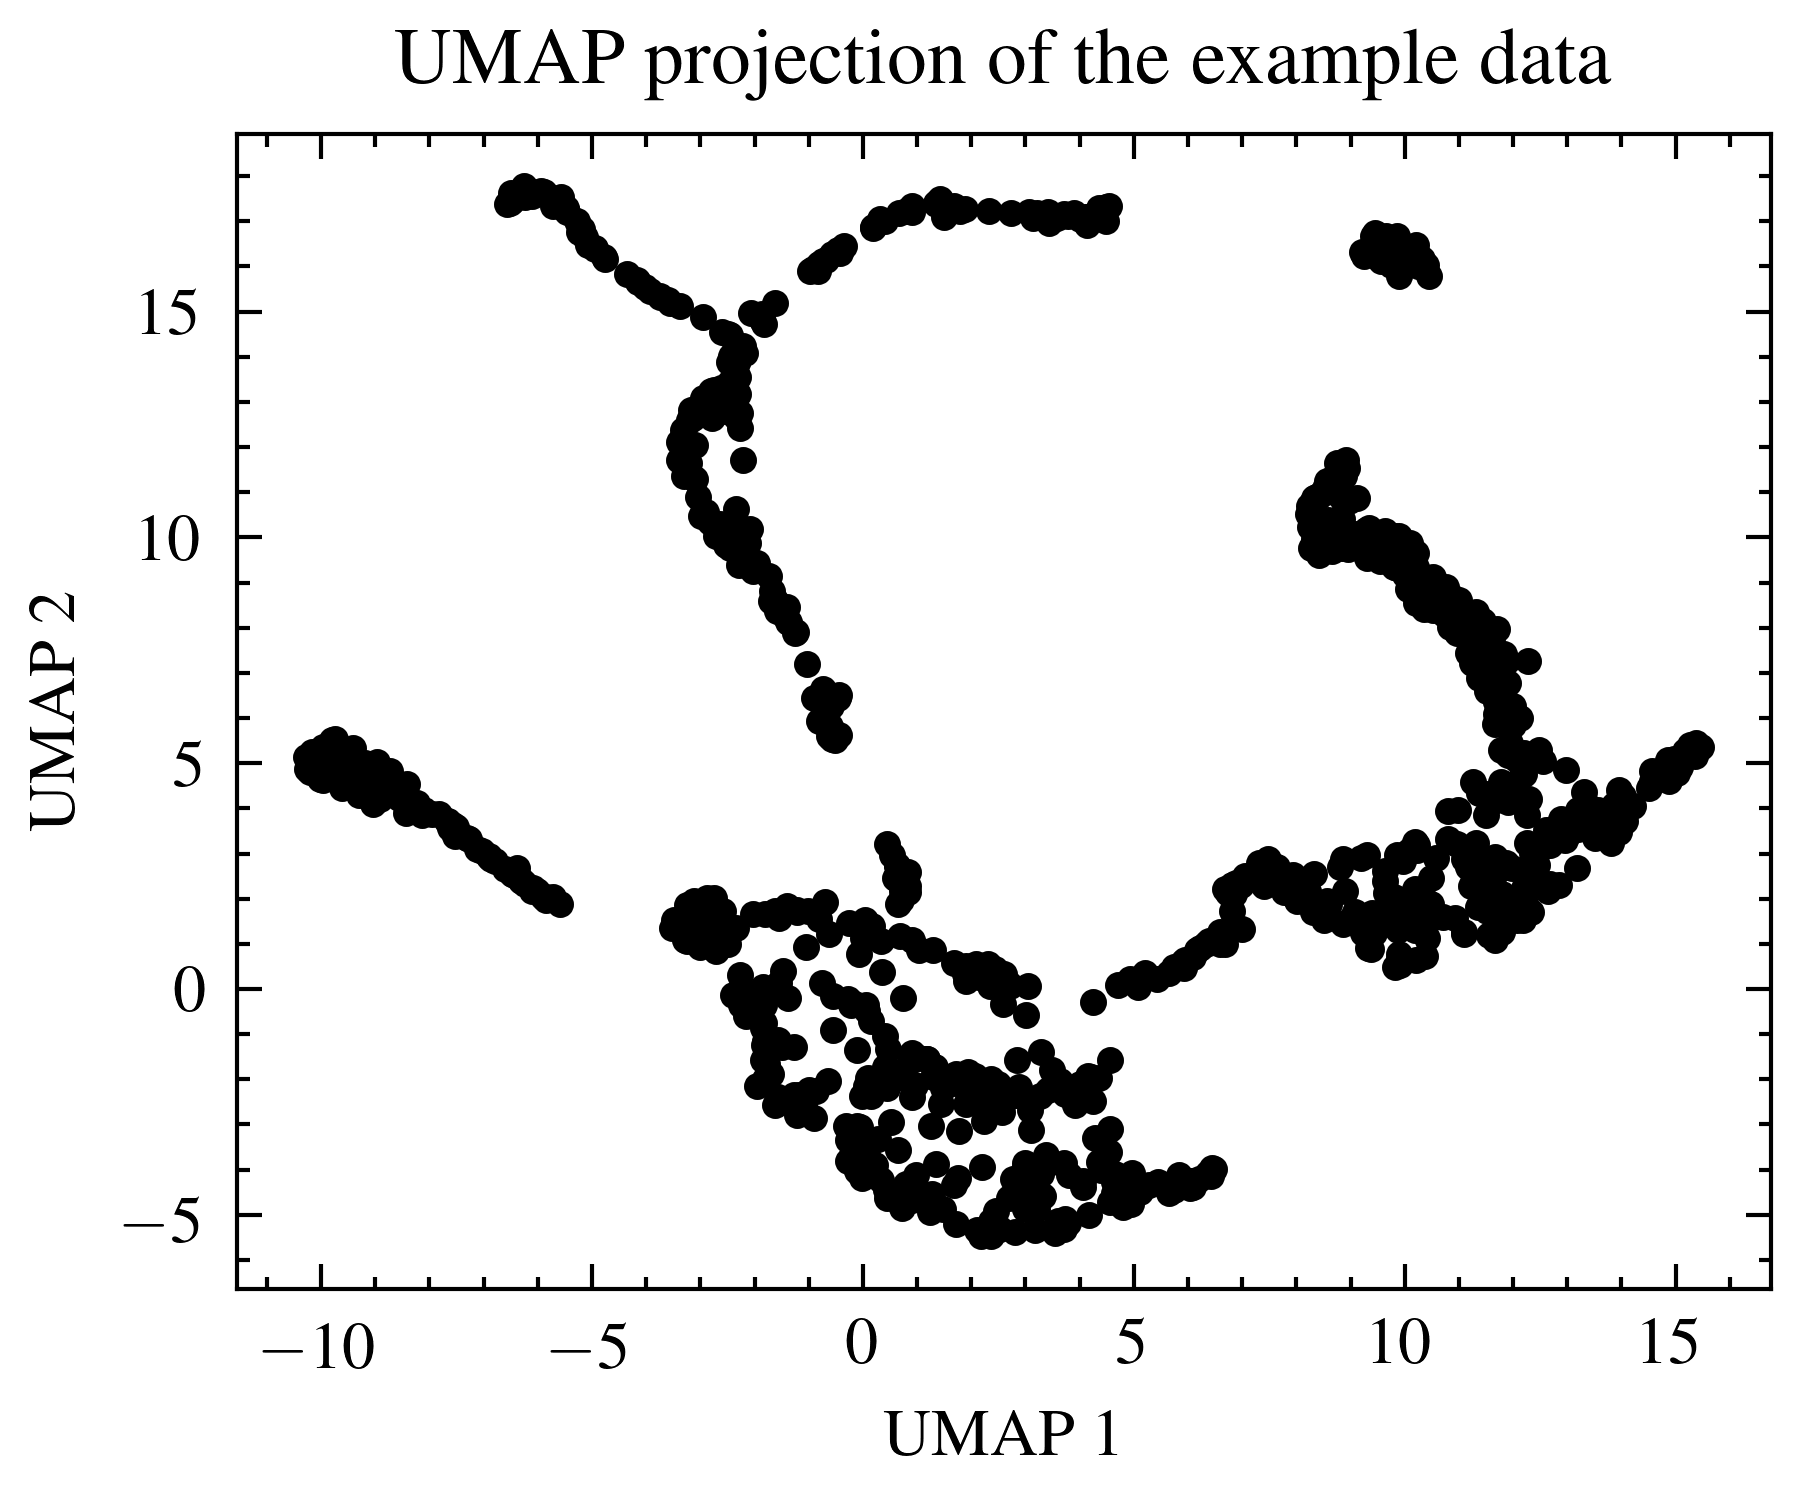

In [4]:
plt.style.use(['science','ieee'])
plt.figure(figsize=(8,8), dpi=200)

# Initialize UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.5)
embedding = reducer.fit_transform(img_features)

# Plot
plt.scatter(embedding[:, 0], embedding[:, 1], s=5)
plt.title('UMAP projection of the example data')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

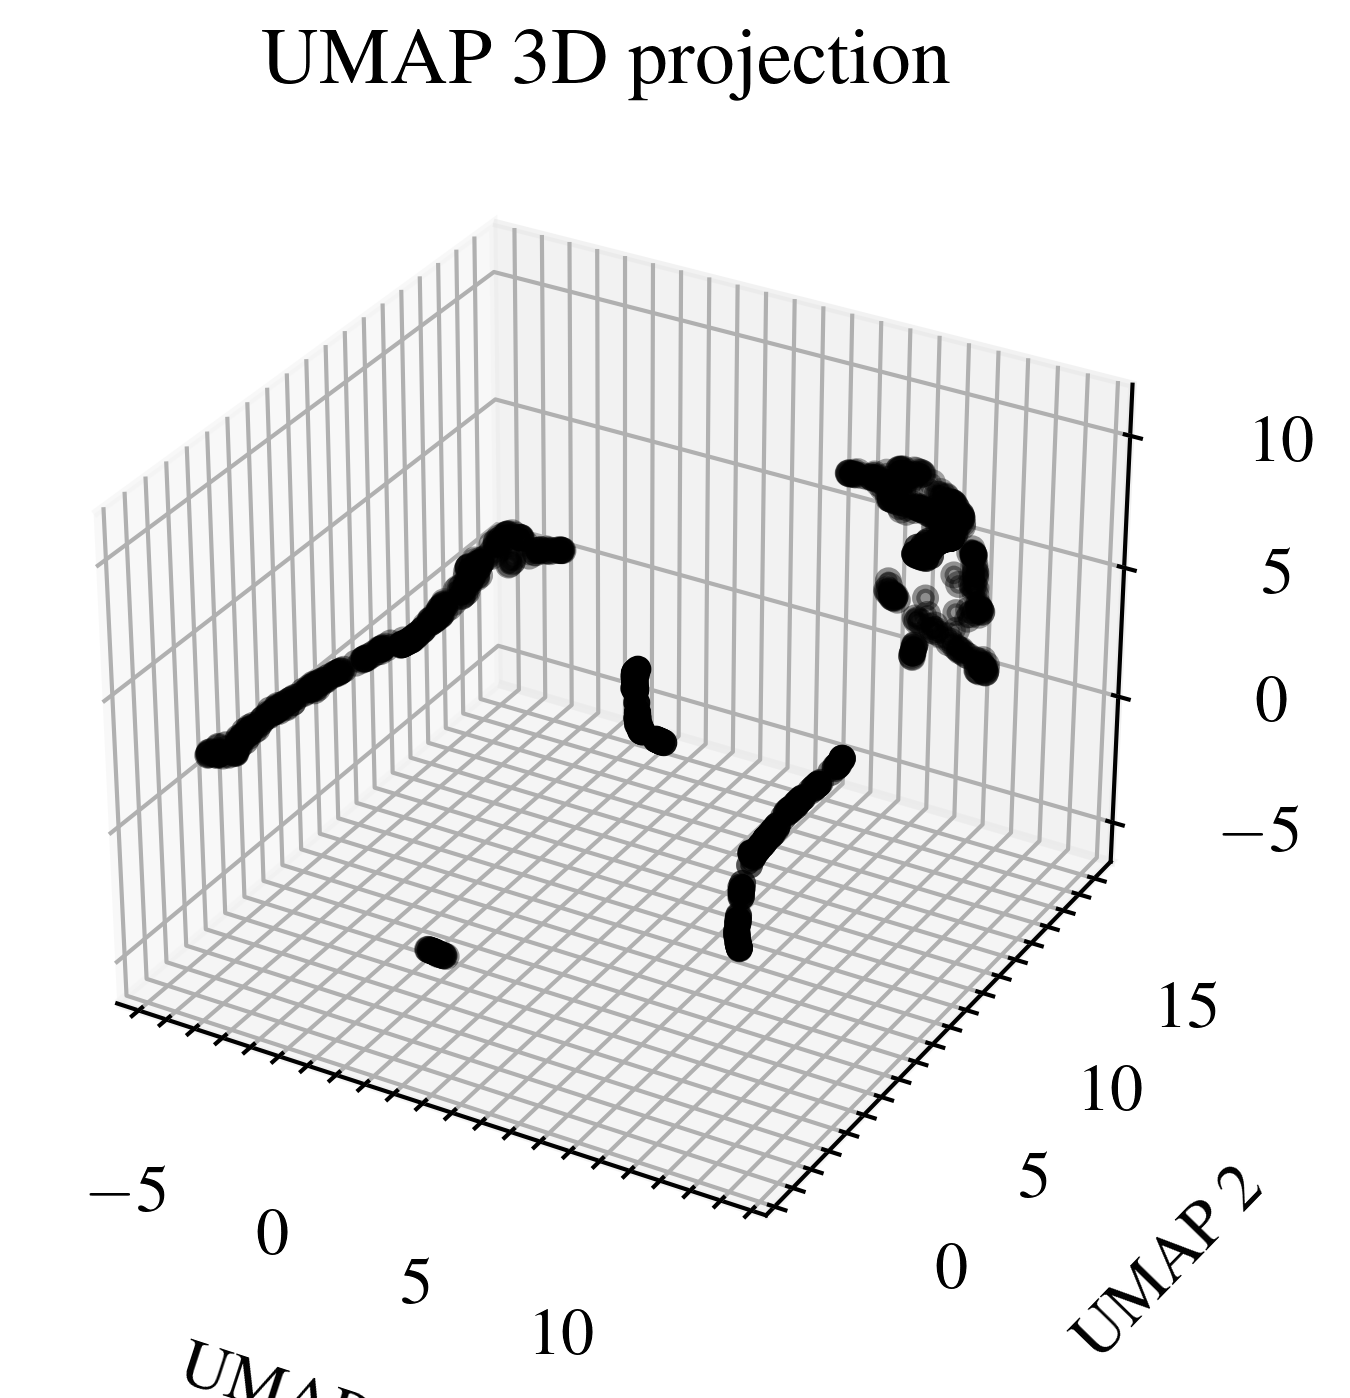

In [5]:
# Plot the 3D embedding
reducer = umap.UMAP(n_components=3)
embedding = reducer.fit_transform(img_features)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], s=5)
ax.set_title('UMAP 3D projection')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
plt.show()

Interactive Run

IntSlider(value=15, description='n_neighbors:', min=2)

FloatSlider(value=0.1, description='min_dist:', max=1.0, min=0.01, step=0.01)

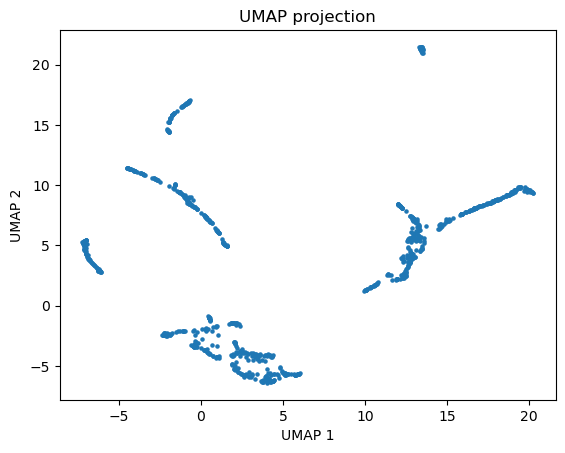

In [3]:
import numpy as np
import umap
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def apply_umap(n_neighbors, min_dist):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
    embedding = reducer.fit_transform(img_features)
    plt.scatter(embedding[:, 0], embedding[:, 1], s=5)
    plt.title('UMAP projection')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()

# Create sliders for adjusting parameters
n_neighbors_slider = widgets.IntSlider(value=15, min=2, max=100, step=1, description='n_neighbors:')
min_dist_slider = widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description='min_dist:')

# Define callback function to update plot when sliders change
def update_plot(change):
    apply_umap(n_neighbors=n_neighbors_slider.value, min_dist=min_dist_slider.value)

# Attach callback function to slider events
n_neighbors_slider.observe(update_plot, 'value')
min_dist_slider.observe(update_plot, 'value')

# Display sliders and initial plot
display(n_neighbors_slider)
display(min_dist_slider)
apply_umap(n_neighbors=n_neighbors_slider.value, min_dist=min_dist_slider.value)